In [2]:
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,"../")
import mplhep as hep
import pickle
import glob
import ROOT
import coffea
import awkward as ak
from coffea import hist, processor
from coffea.nanoevents.methods import candidate
from coffea.nanoevents.methods import vector


Welcome to JupyROOT 6.28/00


In [3]:
eras = ["all", "2022", "2023","2024"]

In [4]:
path_2022 = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/Run2022_L1_Eff_goodLumi.root"
path_2023 = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/Run2023_L1_Eff_goodLumi.root"
path_2024 = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024F-PromptReco-v1-AOD_goodLumi.root"

In [5]:

list_2024 = ["root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024B-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024C-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024D-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024E-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024E-PromptReco-v2-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024F-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024G-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024H-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024I-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon0-Run2024I-PromptReco-v2-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024B-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024C-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024D-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024E-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024E-PromptReco-v2-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024F-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024G-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024H-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024I-PromptReco-v1-AOD_goodLumi.root",
            "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HMT_L1_Eff_Output/2024_Merged/Muon1-Run2024I-PromptReco-v2-AOD_goodLumi.root"]

    

In [6]:
ak.behavior.update(candidate.behavior)

def getLZDF(f,nEvents=-1,version="new"): #lazy dataframe with events that have cluster matched to probe muon
    events_raw = uproot.open(f)['MuonSystem']
    df = coffea.processor.LazyDataFrame(events_raw,entrystop=nEvents)
    start,stop = df._branchargs['entry_start'],df._branchargs['entry_stop']
    events = uproot.lazy(df._tree)
    events = events[start:stop]
    return events

In [7]:
data_events_2024 = [getLZDF(file) for file in list_2024]
events_2024 = ak.concatenate(data_events_2024, axis=0)

In [8]:
events_2024_probeMuonMatched = ak.mask(events_2024, (ak.flatten(events_2024.cscRechitCluster_matchToProbeMuon))&(ak.flatten(events_2024.cscRechitCluster_PassTimeVeto))&(ak.flatten(events_2024.cscRechitClusterNRechitChamberPlus11)+ak.flatten(events_2024.cscRechitClusterNRechitChamberPlus12)+ak.flatten(events_2024.cscRechitClusterNRechitChamberMinus11)+ak.flatten(events_2024.cscRechitClusterNRechitChamberMinus12)==0))
events_2024_probeMuonMatched = events_2024_probeMuonMatched[~ak.is_none(events_2024_probeMuonMatched)]

In [9]:
chamber_locations = {
    "ME11": {"MinR": 100, "MaxR": 275, "minZ": 580, "maxZ": 632, "HLT_thresh": 500, "branch_names": ["cscRechitClusterNRechitChamberMinus11", "cscRechitClusterNRechitChamberPlus11"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 20), np.arange(200, 1000, 100)]))},
    "ME12": {"MinR": 275, "MaxR": 465, "minZ": 668, "maxZ": 725, "HLT_thresh": 200, "branch_names": ["cscRechitClusterNRechitChamberMinus12", "cscRechitClusterNRechitChamberPlus12"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 20), np.arange(200, 1000, 100)]))},
    "ME13": {"MinR": 505, "MaxR": 700, "minZ": 668, "maxZ": 724, "HLT_thresh": 200, "branch_names": ["cscRechitClusterNRechitChamberMinus13", "cscRechitClusterNRechitChamberPlus13"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 20), np.arange(200, 1000, 100)]))},
    "ME21": {"MinR": 139, "MaxR": 345, "minZ": 789, "maxZ": 850, "HLT_thresh": 500, "branch_names": ["cscRechitClusterNRechitChamberMinus21", "cscRechitClusterNRechitChamberPlus21"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 500, 100), np.arange(500, 1000, 400)]))},
    "ME22": {"MinR": 357, "MaxR": 700, "minZ": 791, "maxZ": 850, "HLT_thresh": 200, "branch_names": ["cscRechitClusterNRechitChamberMinus22", "cscRechitClusterNRechitChamberPlus22"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 50), np.arange(200, 1000, 100)]))},
    "ME31": {"MinR": 160, "MaxR": 345, "minZ": 915, "maxZ": 970, "HLT_thresh": 500, "branch_names": ["cscRechitClusterNRechitChamberMinus31", "cscRechitClusterNRechitChamberPlus31"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 500, 100), np.arange(500, 1000, 400)]))},
    "ME32": {"MinR": 357, "MaxR": 700, "minZ": 911, "maxZ": 970, "HLT_thresh": 200, "branch_names": ["cscRechitClusterNRechitChamberMinus32", "cscRechitClusterNRechitChamberPlus32"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 50), np.arange(200, 1000, 100)]))},
    "ME41": {"MinR": 178, "MaxR": 345, "minZ": 1002, "maxZ": 1063, "HLT_thresh": 500, "branch_names": ["cscRechitClusterNRechitChamberMinus41", "cscRechitClusterNRechitChamberPlus41"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 500, 100), np.arange(500, 1000, 400)]))},
    "ME42": {"MinR": 357, "MaxR": 700, "minZ": 1002, "maxZ": 1063, "HLT_thresh": 200, "branch_names": ["cscRechitClusterNRechitChamberMinus42", "cscRechitClusterNRechitChamberPlus42"], "binning": hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 50), np.arange(200, 1000, 100)]))}
}

In [10]:
nRechits_branches = ["cscRechitClusterNRechitChamberMinus11", "cscRechitClusterNRechitChamberPlus11", "cscRechitClusterNRechitChamberMinus12", "cscRechitClusterNRechitChamberPlus12",
                    "cscRechitClusterNRechitChamberMinus13", "cscRechitClusterNRechitChamberPlus13", "cscRechitClusterNRechitChamberMinus21", "cscRechitClusterNRechitChamberPlus21",
                    "cscRechitClusterNRechitChamberMinus22", "cscRechitClusterNRechitChamberPlus22", "cscRechitClusterNRechitChamberMinus31", "cscRechitClusterNRechitChamberPlus31",
                    "cscRechitClusterNRechitChamberMinus32", "cscRechitClusterNRechitChamberPlus32", "cscRechitClusterNRechitChamberMinus41", "cscRechitClusterNRechitChamberPlus41",
                    "cscRechitClusterNRechitChamberMinus42", "cscRechitClusterNRechitChamberPlus42"]

In [11]:
def noisy_cluster_events(data):
    return (((ak.flatten(data.cscRechitClusterPhi)>0.4) & (ak.flatten(data.cscRechitClusterPhi)<0.8))|(np.abs(ak.flatten(data.cscRechitClusterPhi))>2.8))

In [12]:
#code to mask for clusters for which majority of events are in designated chamber
#require greater than 90% of hits to be in given chamber as well
def compute_chamber_mask(data, chamber, threshold, endcap=None):
    nRechits_byChamber = {}
    final_masks = []
    for x in range(2):
        correct_chamber_branch = chamber_locations[chamber]["branch_names"][x]
        incorrect_chamber_branches = []
        for chamber_branch in nRechits_branches:
            if chamber_branch != correct_chamber_branch:
                incorrect_chamber_branches.append(chamber_branch)         
        mask = ak.flatten(data[correct_chamber_branch])>ak.flatten(data[incorrect_chamber_branches[0]])
        for idx in range(1, len(incorrect_chamber_branches)):
            mask = np.logical_and(mask, ak.flatten(data[correct_chamber_branch])>ak.flatten(data[incorrect_chamber_branches[idx]]))
        mask = np.logical_and(mask, (ak.flatten(data[correct_chamber_branch])/ak.flatten(data["cscRechitClusterSize"])>=threshold))
        #print(np.count_nonzero(mask))
        #code to mask out negative endcap clusters in problematic region
        if x==0 and (chamber=="ME31" or chamber=="ME41"):
        #    print("applying mask")
             mask = np.logical_and(mask, np.logical_not(noisy_cluster_events(data)))
        #print(ak.count_nonzero(mask))
        final_masks.append(mask)
    if endcap==None:
        return np.logical_or(final_masks[0], final_masks[1])
    else:
        return final_masks[endcap]

In [13]:
#function to to return ratio histograms
def get_efficiency_hists(data, chamber_list, bins, endcap=None, justTight=False):
    
    subMasks = []
    for chamber in chamber_list:
        threshold=0.9 
        subMasks.append(np.array(compute_chamber_mask(data, chamber, threshold, endcap)))
    
    
    total_mask = np.logical_or.reduce(np.array(subMasks))
    denom = ak.mask(ak.flatten(data.cscRechitClusterSize), total_mask)
    
    #checking just tight
    if justTight:
        num = ak.mask(denom, data.L1_SingleMuShower_Tight)
    else:
        num = ak.mask(denom, ak.mask(np.logical_or(data.L1_SingleMuShower_Nominal, data.L1_SingleMuShower_Tight),total_mask))

    denom = denom[~ak.is_none(denom)]
    num = num[~ak.is_none(num)]
    
    num_hist = hist.Hist("Counts", rechits_axis, bins)
    arr_to_fill = num
    num_hist.fill(sample = f"{ak.count(arr_to_fill)} entries", cluster_size=arr_to_fill)

    denom_hist = hist.Hist("Counts", rechits_axis, bins)
    arr_to_fill = denom
    denom_hist.fill(sample = f"{ak.count(arr_to_fill)} entries", cluster_size=arr_to_fill)

    return num_hist, denom_hist


In [14]:
#colors = ["green", "red", "black"]
colors = ["black"]
center_of_mass_energy = 13.6
rechits_axis = hist.Cat("sample", "sample")

In [15]:
#two sets of binning, one for inner ring (ME41) and one for outer ring (ME22)
bins_ME41 = hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 500, 100), np.arange(500, 1000, 400)]))
bins_ME22 = hist.Bin("cluster_size", "Cluster Size", np.concatenate([np.arange(0, 200, 50), np.arange(200, 1000, 100)]))

In [16]:
plt.style.use(hep.style.CMS)

In [17]:
import pickle as pkl
pickle_filename = "HMT_Effciencies_CoffeaHists_2024_082727_Cleaned.pkl"

In [18]:
coffea_hists = {}

In [ ]:
#myString = "newMerge_forPaper_032625"
plt.figure(figsize=(14,10))
chamber_list = ["ME42"]
#chamber_list = ["ME13", "ME22", "ME32", "ME42"]
#chamber_list = ["ME21", "ME31", "ME41"]

bins = bins_ME22
for chamber in chamber_list:
    chamber_with_slash = chamber[:3] + '/' + chamber[3]
    print(chamber)
    num_hist, denom_hist = get_efficiency_hists(events_2024_probeMuonMatched, [chamber], bins)
    coffea_hists[chamber+"_num"] = num_hist
    coffea_hists[chamber+"_denom"] = denom_hist

ME42


In [ ]:
# chamber_list = ["ME21", "ME31", "ME41"]
# chamber_with_slash = chamber[:3] + '/' + chamber[3]
bins = bins_ME41
for chamber in chamber_list:
    print(chamber)
    labelName = sample
    num_hist, denom_hist = get_efficiency_hists(events_2024_probeMuonMatched, [chamber], bins)
    coffea_hists[chamber+"_num"] = num_hist
    coffea_hists[chamber+"_denom"] = denom_hist

In [ ]:
with open(pickle_filename, "wb") as f:
    pkl.dump(coffea_hists, f)

## USED FOR DP NOTE, NOT NEEDED FOR LOADING HISTS TO PKL, COMPUTE HISTS HERE WITHOUT PKL

232
629
861


/cvmfs/sft.cern.ch/lcg/views/LCG_103/x86_64-centos7-gcc11-opt/lib/python3.9/site-packages/coffea/hist/plot.py:427: RuntimeWarning: invalid value encountered in true_divide
  rsumw = sumw_num / sumw_denom


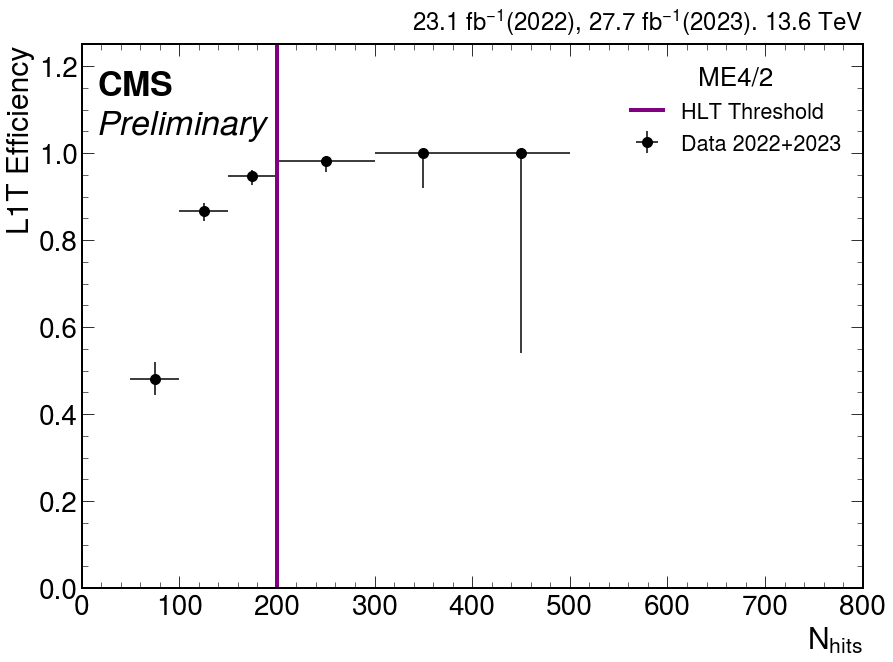

In [36]:
myString = "newMerge_forPaper_032625"
plt.figure(figsize=(14,10))
chamber="ME42"
chamber_list = ["ME42"]
chamber_with_slash = chamber[:3] + '/' + chamber[3]
bins = bins_ME22
for num, sample in enumerate(['all']):
    #if sample=='all':
        #labelName = '2022 + 2023'
    if num==0:
        plt.axvline(chamber_locations["ME42"]["HLT_thresh"], color="purple", label="HLT Threshold", linewidth=4)
    
    labelName = sample
    num_hist, denom_hist = get_efficiency_hists(events_all_probeMuonMatched, chamber_list, bins)
    coffea_hists[chamber+"_num"] = num_hist
    coffea_hists[chamber+"_denom"] = denom_hist
     
    
    hist.plotratio(
        ax=plt.gca(),
        num =num_hist.project(bins),
        denom=denom_hist.project(bins),
        error_opts={'marker': '.', 'markersize': 20, 'color':colors[num]},
        unc='clopper-pearson',
        label= "Data 2022+2023",
        clear=False,
        xerr=True
        )
handles, labels = plt.gca().get_legend_handles_labels()
order = [0,3,1,2]

#plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], title=chamber_with_slash, loc=8)
plt.legend(title=chamber_with_slash)
plt.xlabel("$\mathregular{N_{hits}}$", fontsize=30)
plt.ylabel("L1T Efficiency", fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=28)
#hep.cms.label(ax=plt.gca(),data=True, lumi="50.8", fontsize=28, loc=2,COM=13.6)
plt.gca().text(1.0, 1.07, "23.1 $\mathregular{fb^{-1}}$(2022), 27.7 $\mathregular{fb^{-1}}$(2023). 13.6 TeV", transform=plt.gca().transAxes,
        fontsize=24, verticalalignment='top', horizontalalignment='right')
plt.gca().text(0.02, 0.95, r"$\bf{CMS}$"+"\n"+r"$\it{Preliminary}$", transform=plt.gca().transAxes, fontsize=34, verticalalignment='top', horizontalalignment='left')
plt.xlim(0,800)
plt.ylim(0, 1.25)
#plt.title("Matched to Probe Muon - Positive Endcap", fontsize=24)
plt.savefig(f"L1_Efficiency_Plots/{chamber}_{myString}.png")